# Step 3.1 — Modeling: Random Forest (classical baseline)
## Dataset B — PlantVillage (raw, disease classification)

This notebook trains a **single model** — a **Random Forest with balanced class weights** — on the PlantVillage disease data, as one of the classical baselines for Step 3.1. It is written to **stand alone**: it produces the forest's **validation macro-F1, per-class recall, and confusion matrix**, saves the trained model, and stops there. Combining it with the other models into one comparison table is left for later.

**The feature representation.** A tree model needs a fixed-length numeric vector per image, not raw pixels. Deliverable 1 (Figures 3–5) showed the six *global* summary features (brightness, colour means, file size, green fraction) are redundant and barely separate the classes, so this notebook builds the forest a richer, still-classical descriptor — **colour histograms (RGB + HSV) plus GLCM texture** (~160 numbers per image) — the kind of hand-crafted representation classical computer vision used before deep learning.

**What it inherits from Deliverable 1 (so it lines up when combined later):**
- the raw **color** PlantVillage images (38 classes, 54,305 images);
- the **file-level, stratified, leakage-free 70/15/15 split** — loaded from the same shared CSVs (Section 7.3);
- **class weights** for the ~36:1 imbalance (Section 7.7), passed to the forest as `class_weight="balanced"`.

**Test-set discipline.** The held-out **test set is loaded but never touched** — sealed for Deliverable 2. Every score here is on the **validation** set.

Each cell carries a short **why / how it fits** note, paths are auto-discovered, and the feature-extraction step is cached so re-runs are quick.

> **Runtime:** no GPU needed. The one-off feature extraction over the full split takes a few minutes, then it is cached.

## Colab setup — run this first

On **Google Colab** the dataset is pulled from Kaggle, which needs your Kaggle API key. We use **Colab Secrets** so the key never lives in the notebook (same setup as the other notebooks):

1. Open your `kaggle.json` (it reads `{"username": "...", "key": "..."}`).
2. In the left sidebar, click the **key icon (Secrets)** → **Add new secret** twice, each with **Notebook access** on: `KAGGLE_USERNAME` and `KAGGLE_KEY`.
3. Run the cell below, then **Runtime ▸ Run all**.

*(Run locally, this cell does nothing and the notebook uses your local `~/.kaggle/kaggle.json` instead.)*

In [ ]:
# Colab: load Kaggle credentials from Colab Secrets. Harmless when run locally.
import os
try:
    from google.colab import userdata
    os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
    os.environ["KAGGLE_KEY"]      = userdata.get("KAGGLE_KEY")
    print("Kaggle credentials loaded from Colab Secrets.")
except ModuleNotFoundError:
    pass  # not on Colab - falls back to local ~/.kaggle/kaggle.json

Kaggle credentials loaded from Colab Secrets.


## 0. Setup and configuration

Imports, one fixed seed, the shared paths, and a single config block. The **paths matter**: the split CSVs live in the baseline folder (`step3_baseline/`) so this notebook reads the *same* train/val/test files as the rest of Step 3.1 — that is what will make the models line up when you combine them later.

**Why run it:** a Colab kernel forgets every variable on restart; the fixed seed keeps the split and the forest reproducible.

**How it fits:** it locks this notebook onto the same data and conventions as the rest of Step 3.1.

In [ ]:
# Imports, seed, shared paths, and the run configuration
from pathlib import Path
from collections import deque
import os, time, random, json
import numpy as np, pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (f1_score, recall_score, accuracy_score,
                             confusion_matrix, classification_report)
import joblib

# scikit-image supplies the colour-space conversion and the GLCM texture features
try:
    from skimage.color import rgb2hsv, rgb2gray
    from skimage.feature import graycomatrix, graycoprops
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "scikit-image"])
    from skimage.color import rgb2hsv, rgb2gray
    from skimage.feature import graycomatrix, graycoprops

sns.set_theme()
SEED = 42
random.seed(SEED); np.random.seed(SEED)

# ---- paths ----------------------------------------------------------------
# The SPLIT lives in the Step-3.1 baseline folder and is SHARED, so this forest
# uses the exact same train/val/test files as the other models. RF-specific
# artifacts go in their own folder.
BASE        = Path.home() / "plant_recognition"
PV_DIR      = BASE / "plantvillage"
SPLIT_DIR   = BASE / "step3_baseline"; SPLIT_DIR.mkdir(parents=True, exist_ok=True)
RF_DIR      = BASE / "step3_rf";       RF_DIR.mkdir(parents=True, exist_ok=True)
SPLIT_CSV   = {s: SPLIT_DIR / f"split_{s}.csv" for s in ("train", "val", "test")}
FEAT_TRAIN_NPZ = RF_DIR / "features_train.npz"
FEAT_VAL_NPZ   = RF_DIR / "features_val.npz"
IMG_EXTS    = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tif", ".tiff"}

# ---- run configuration (everything tunable in one place) ------------------
SPLIT        = (0.70, 0.15, 0.15)      # train / val / test  (Deliverable 1, Section 7.3)
FEAT_SIZE    = 64                      # images are downsized to 64x64 for the histogram/texture features
RGB_BINS     = 32                      # per-channel RGB colour-histogram bins
HSV_BINS     = 16                      # per-channel HSV colour-histogram bins
GLCM_LEVELS  = 32                      # grey levels for the co-occurrence matrix (cost ~ levels^2)
GLCM_DIST    = [1, 2]                  # pixel offsets for GLCM
GLCM_ANGLES  = [0, np.pi/4, np.pi/2, 3*np.pi/4]     # averaged over -> rotation-robust
GLCM_PROPS   = ["contrast", "dissimilarity", "homogeneity", "energy", "correlation"]
N_ESTIMATORS = 300                     # trees in the forest
RF_TRAIN_CAP = None                    # None = fit on the FULL training split; set an int to cap per class

# Smoke test: flip to True for a quick end-to-end dry run before the full extraction.
SMOKE_TEST      = False
SMOKE_PER_CLASS = 60

print("Config: FEAT_SIZE={}, RGB_BINS={}, HSV_BINS={}, GLCM_LEVELS={}, N_ESTIMATORS={}, SMOKE_TEST={}".format(
      FEAT_SIZE, RGB_BINS, HSV_BINS, GLCM_LEVELS, N_ESTIMATORS, SMOKE_TEST))

Config: FEAT_SIZE=64, RGB_BINS=32, HSV_BINS=16, GLCM_LEVELS=32, N_ESTIMATORS=300, SMOKE_TEST=False


## 1. Download the raw dataset (skips if already present)

Fetches PlantVillage from Kaggle and **skips if it is already on disk** — so if you ran another notebook in this session it is reused instantly.

**Why run it:** we need the raw images locally to compute features; the skip-guard avoids re-downloading gigabytes.

**How it fits:** the same untouched source as every other notebook — clean, shared provenance.

In [ ]:
# Download raw PlantVillage from Kaggle (skips if PV_DIR is non-empty; needs kaggle.json)
if not PV_DIR.exists() or not any(PV_DIR.iterdir()):
    from kaggle.api.kaggle_api_extended import KaggleApi
    PV_DIR.mkdir(parents=True, exist_ok=True)
    api = KaggleApi(); api.authenticate()
    api.dataset_download_files("abdallahalidev/plantvillage-dataset",
                               path=str(PV_DIR), unzip=True, quiet=False)
    print("Downloaded to", PV_DIR)
else:
    print("Already present:", PV_DIR)

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset


100%|██████████| 2.04G/2.04G [00:08<00:00, 247MB/s]



Downloaded to /root/plant_recognition/plantvillage


## 2. Locate the `color` rendering and confirm the 38 classes

The archive nests `color`, `grayscale` and `segmented` inside a wrapper folder. We locate the **color** copy automatically (same helper as the other notebooks) and confirm the class list and its canonical sorted order.

**Why run it:** hard-coded paths break across machines; auto-discovery does not.

**How it fits:** it pins the exact folder and the sorted class order the integer labels use everywhere.

In [ ]:
# Breadth-first search for the 'color' folder, then list the classes (sorted = canonical label order)
def locate(root, names, max_depth=4):
    q = deque([(root, 0)])
    while q:
        d, depth = q.popleft()
        if d.is_dir() and d.name.lower() in names:
            return d
        if d.is_dir() and depth < max_depth:
            for c in sorted(d.iterdir()):
                if c.is_dir():
                    q.append((c, depth + 1))
    return None

COLOR_DIR = locate(PV_DIR, {"color"})
assert COLOR_DIR is not None, "Could not find a 'color' folder under PV_DIR - check the path."
class_names = sorted([d.name for d in COLOR_DIR.iterdir() if d.is_dir()])
name2idx    = {n: i for i, n in enumerate(class_names)}       # label -> integer index (used everywhere)
n_classes   = len(class_names)
print("color dir:", COLOR_DIR)
print(f"classes: {n_classes}")
assert n_classes == 38, f"expected 38 classes, found {n_classes}"
print("first / last class:", class_names[0], "/", class_names[-1])

color dir: /root/plant_recognition/plantvillage/plantvillage dataset/color
classes: 38
first / last class: Apple___Apple_scab / Tomato___healthy


## 3. Load the canonical, leakage-free 70/15/15 split

If the split CSVs already exist (saved by another Step 3.1 notebook), we **load them** — so this forest uses the *identical* train/val/test files. If they are missing (e.g. this notebook runs first), we rebuild them with the **same seed and the same stratified `train_test_split ×2`**, which is deterministic and produces the same split anyway, and save them back for everyone.

**Why run it:** using the shared split is what will let the models line up in one comparison later.

**How it fits:** it is the exact split Deliverable 1 (Section 7.3) defends.

In [ ]:
# Build (or load) the canonical file-level stratified split, then verify it
def enumerate_files(color_dir):
    paths, labels = [], []
    for c in class_names:
        for f in sorted((color_dir / c).iterdir()):
            if f.suffix.lower() in IMG_EXTS:
                paths.append(str(f)); labels.append(c)
    return np.array(paths), np.array(labels)

if all(p.exists() for p in SPLIT_CSV.values()):
    # Reuse the canonical split saved by another notebook / a teammate -> identical splits
    dfs = {s: pd.read_csv(SPLIT_CSV[s]) for s in SPLIT_CSV}
    p_tr,  y_tr  = dfs["train"]["filepath"].values, dfs["train"]["label"].values
    p_val, y_val = dfs["val"]["filepath"].values,   dfs["val"]["label"].values
    p_te,  y_te  = dfs["test"]["filepath"].values,  dfs["test"]["label"].values
    print("Loaded saved split from CSV (canonical, shared).")
else:
    paths, labels = enumerate_files(COLOR_DIR)
    print(f"enumerated {len(paths):,} image files")
    test_frac = SPLIT[2]
    val_frac_of_rest = SPLIT[1] / (SPLIT[0] + SPLIT[1])
    p_tr, p_te, y_tr, y_te = train_test_split(
        paths, labels, test_size=test_frac, stratify=labels, random_state=SEED)
    p_tr, p_val, y_tr, y_val = train_test_split(
        p_tr, y_tr, test_size=val_frac_of_rest, stratify=y_tr, random_state=SEED)
    for s, (pp, yy) in {"train": (p_tr, y_tr), "val": (p_val, y_val), "test": (p_te, y_te)}.items():
        pd.DataFrame({"filepath": pp, "label": yy}).to_csv(SPLIT_CSV[s], index=False)
    print("Built split with train_test_split x2 (stratified) and saved CSVs (now shared).")

# ---- verify: sizes, every class present in each set, and no leakage across sets ----
print(f"\ntrain / val / test : {len(p_tr):,} / {len(p_val):,} / {len(p_te):,}"
      f"  ({len(p_tr)/(len(p_tr)+len(p_val)+len(p_te)):.0%} / "
      f"{len(p_val)/(len(p_tr)+len(p_val)+len(p_te)):.0%} / "
      f"{len(p_te)/(len(p_tr)+len(p_val)+len(p_te)):.0%})")
for nm, yy in [("train", y_tr), ("val", y_val), ("test", y_te)]:
    assert set(yy) == set(class_names), f"{nm} is missing classes!"
s_tr, s_val, s_te = set(p_tr), set(p_val), set(p_te)
assert s_tr.isdisjoint(s_val) and s_tr.isdisjoint(s_te) and s_val.isdisjoint(s_te), "LEAKAGE: sets overlap!"
print("verified: all 38 classes present in each split, and the three sets are disjoint (no leakage).")
print("NOTE: the test set is loaded here but is NOT used again - it is reserved for Deliverable 2.")

enumerated 54,305 image files
Built split with train_test_split x2 (stratified) and saved CSVs (now shared).

train / val / test : 38,013 / 8,146 / 8,146  (70% / 15% / 15%)
verified: all 38 classes present in each split, and the three sets are disjoint (no leakage).
NOTE: the test set is loaded here but is NOT used again - it is reserved for Deliverable 2.


## 4. Class weights from the training split

Weights **inversely proportional to class frequency**, from the **training labels only** (Section 7.7). We print them for reference and pass `class_weight="balanced"` to the forest, which applies the same idea while fitting.

**Why run it:** at ~36:1 the forest would otherwise chase the big Tomato/Orange classes and ignore the rare ones (healthy Potato, 152 images).

**How it fits:** it is the imbalance remedy the report specified — applied here to the classical model, as Habiba's note reminded.

In [ ]:
# Balanced class weights from the FULL training split (for reference + passed to the RF)
yi_tr_full = np.array([name2idx[y] for y in y_tr], dtype="int64")
weights = compute_class_weight("balanced", classes=np.arange(n_classes), y=yi_tr_full)
class_weight = {i: float(w) for i, w in enumerate(weights)}
print("weight range on full train: {:.2f} (most common) ... {:.2f} (rarest)".format(
      min(class_weight.values()), max(class_weight.values())))
top = sorted(class_weight.items(), key=lambda kv: kv[1], reverse=True)[:3]
print("highest-weighted (rarest) classes:", [(class_names[i], round(w, 1)) for i, w in top])
print("The RF is trained with class_weight='balanced', so it recomputes these on the data it is fit on.")

weight range on full train: 0.26 (most common) ... 9.44 (rarest)
highest-weighted (rarest) classes: [('Potato___healthy', 9.4), ('Apple___Cedar_apple_rust', 5.2), ('Peach___healthy', 4.0)]
The RF is trained with class_weight='balanced', so it recomputes these on the data it is fit on.


## 5. The feature vector — colour histograms + GLCM texture

For each image we build a **~160-number descriptor**:

- **RGB colour histograms** — per-channel distributions of colour (32 bins each): *how much of each colour tone is present.*
- **HSV colour histograms** — hue / saturation / value (16 bins each): often more disease-informative than raw RGB, since lesions shift hue and saturation.
- **GLCM texture** — grey-level co-occurrence features (contrast, dissimilarity, homogeneity, energy, correlation), averaged over four directions: *how rough or patterned the surface is* — the closest a hand-crafted feature gets to "spots and lesions."
- **The six global features** from Deliverable 1, appended so the forest can use them too.

Histograms and texture are computed on a **64×64** copy for speed; the six global features keep their **full-resolution** Deliverable-1 definition. Everything is **cached to disk**, so the (few-minute) extraction runs once.

**Why run it:** the forest needs a fixed-length numeric vector per image, not raw pixels; this is where the classical signal is engineered in.

**How it fits:** it is the representation the Random Forest is trained on.

In [ ]:
# ---- feature specification: which columns, and which GROUP each column belongs to ----
def build_feature_spec():
    names, groups = [], []
    for ch in ["R", "G", "B"]:
        names += [f"rgb_{ch}_{b}" for b in range(RGB_BINS)]; groups += ["rgb_hist"] * RGB_BINS
    for ch in ["H", "S", "V"]:
        names += [f"hsv_{ch}_{b}" for b in range(HSV_BINS)]; groups += ["hsv_hist"] * HSV_BINS
    for d in GLCM_DIST:
        names += [f"glcm_d{d}_{p}" for p in GLCM_PROPS]; groups += ["glcm_texture"] * len(GLCM_PROPS)
    names  += ["file_size_kb", "brightness", "mean_R", "mean_G", "mean_B", "green_frac"]
    groups += ["global6"] * 6
    return names, groups

FEATURE_NAMES, FEATURE_GROUPS = build_feature_spec()
print(f"{len(FEATURE_NAMES)} features:",
      {g: FEATURE_GROUPS.count(g) for g in ["rgb_hist", "hsv_hist", "glcm_texture", "global6"]})

def norm_hist(values, bins, rng):
    h = np.histogram(values, bins=bins, range=rng)[0].astype("float64")
    s = h.sum()
    return h / s if s > 0 else h

def extract_features(fp):
    # 6 global features on the FULL-resolution image (identical definition to Deliverable 1)
    a0 = np.asarray(Image.open(fp).convert("RGB")).astype("float64")
    r, g, b = (a0[:, :, i].mean() for i in range(3)); br = a0[:, :, :3].mean()
    global6 = np.array([os.path.getsize(fp) / 1024, br, r, g, b, g / (r + g + b)])

    # histograms + texture on a cheap, scale-robust 64x64 copy
    arr = np.asarray(Image.fromarray(a0.astype("uint8")).resize((FEAT_SIZE, FEAT_SIZE))).astype("float64")
    rgb_hist = np.concatenate([norm_hist(arr[:, :, c], RGB_BINS, (0, 255)) for c in range(3)])
    hsv = rgb2hsv(arr / 255.0)
    hsv_hist = np.concatenate([norm_hist(hsv[:, :, c], HSV_BINS, (0, 1)) for c in range(3)])
    gray = (rgb2gray(arr / 255.0) * (GLCM_LEVELS - 1)).astype("uint8")
    glcm = graycomatrix(gray, distances=GLCM_DIST, angles=GLCM_ANGLES,
                        levels=GLCM_LEVELS, symmetric=True, normed=True)
    prop = {p: graycoprops(glcm, p).mean(axis=1) for p in GLCM_PROPS}   # each -> (n_dist,)
    glcm_feats = np.array([prop[p][di] for di in range(len(GLCM_DIST)) for p in GLCM_PROPS])

    return np.concatenate([rgb_hist, hsv_hist, glcm_feats, global6]).astype("float32")

def featurize(paths, labels, cache_npz, use_cache):
    if use_cache and cache_npz.exists():
        d = np.load(cache_npz, allow_pickle=True)
        print(f"  loaded cached features {d['X'].shape} <- {cache_npz.name}")
        return d["X"], d["y"]
    X = np.zeros((len(paths), len(FEATURE_NAMES)), dtype="float32"); ok = np.ones(len(paths), bool)
    t0 = time.time()
    for i, fp in enumerate(paths):
        try:
            X[i] = extract_features(fp)
        except Exception:
            ok[i] = False
        if (i + 1) % 2000 == 0:
            print(f"  {i+1:,}/{len(paths):,}  ({time.time()-t0:.0f}s)")
    X, y = X[ok], np.asarray(labels)[ok]
    if use_cache:
        np.savez_compressed(cache_npz, X=X, y=y)
    print(f"  featurized {X.shape} in {time.time()-t0:.0f}s"
          + (f"  -> cached {cache_npz.name}" if use_cache else ""))
    return X, y

160 features: {'rgb_hist': 96, 'hsv_hist': 48, 'glcm_texture': 10, 'global6': 6}


In [ ]:
# Choose the fit set (full train by default), then featurize train + val (cached)
def cap_per_class(paths, labels, cap, seed=SEED):
    rng = random.Random(seed); by = {}
    for p, l in zip(paths, labels): by.setdefault(l, []).append(p)
    op, ol = [], []
    for l, ps in by.items():
        sel = ps if len(ps) <= cap else rng.sample(ps, cap)
        op += sel; ol += [l] * len(sel)
    idx = np.arange(len(op)); rng.shuffle(idx)
    return np.array(op)[idx], np.array(ol)[idx]

if SMOKE_TEST:
    fp_tr, fl_tr   = cap_per_class(p_tr, y_tr, SMOKE_PER_CLASS)
    fp_val, fl_val = cap_per_class(p_val, y_val, max(20, SMOKE_PER_CLASS // 3))
elif RF_TRAIN_CAP:
    fp_tr, fl_tr   = cap_per_class(p_tr, y_tr, RF_TRAIN_CAP)
    fp_val, fl_val = p_val, y_val
else:
    fp_tr, fl_tr   = p_tr, y_tr
    fp_val, fl_val = p_val, y_val

use_cache = (not SMOKE_TEST and RF_TRAIN_CAP is None)   # only cache the full, canonical run
print(f"fitting on {len(fp_tr):,} train images; scoring on {len(fp_val):,} val images"
      f"  (feature cache {'ON' if use_cache else 'OFF'})")
print("extracting TRAIN features..."); Xtr,  ytr  = featurize(fp_tr,  fl_tr,  FEAT_TRAIN_NPZ, use_cache)
print("extracting VAL features...");   Xval, yval = featurize(fp_val, fl_val, FEAT_VAL_NPZ,   use_cache)
ytr_i  = np.array([name2idx[l] for l in ytr])
yval_i = np.array([name2idx[l] for l in yval])
print("feature matrices:", Xtr.shape, Xval.shape)

fitting on 38,013 train images; scoring on 8,146 val images  (feature cache ON)
extracting TRAIN features...
  2,000/38,013  (14s)
  4,000/38,013  (28s)
  6,000/38,013  (42s)
  8,000/38,013  (56s)
  10,000/38,013  (70s)
  12,000/38,013  (84s)
  14,000/38,013  (99s)
  16,000/38,013  (112s)
  18,000/38,013  (126s)
  20,000/38,013  (140s)
  22,000/38,013  (154s)
  24,000/38,013  (168s)
  26,000/38,013  (182s)
  28,000/38,013  (196s)
  30,000/38,013  (212s)
  32,000/38,013  (227s)
  34,000/38,013  (241s)
  36,000/38,013  (255s)
  38,000/38,013  (269s)
  featurized (38013, 160) in 273s  -> cached features_train.npz
extracting VAL features...
  2,000/8,146  (14s)
  4,000/8,146  (28s)
  6,000/8,146  (42s)
  8,000/8,146  (56s)
  featurized (8146, 160) in 58s  -> cached features_val.npz
feature matrices: (38013, 160) (8146, 160)


## 6. Fit the Random Forest (with class weights)

Train **300 trees** on the full training features with `class_weight="balanced"`. A forest needs no feature scaling (it splits on thresholds), so there is no `StandardScaler` step.

**Why run it:** this is the model itself.

**How it fits:** its validation metrics come next.

In [ ]:
# Train the Random Forest with balanced class weights (the imbalance remedy for this model)
t0 = time.time()
rf = RandomForestClassifier(n_estimators=N_ESTIMATORS, class_weight="balanced",
                            n_jobs=-1, random_state=SEED)
rf.fit(Xtr, ytr_i)
print(f"trained {N_ESTIMATORS} trees on {Xtr.shape[0]:,} x {Xtr.shape[1]} features in {time.time()-t0:.0f}s")

trained 300 trees on 38,013 x 160 features in 148s


## 7. Evaluate on the validation set

**Macro-F1**, **per-class recall**, and a **row-normalised confusion matrix**, all on the **validation** set (Deliverable 1, Section 8), because plain accuracy flatters an imbalanced classifier.

In [ ]:
# Score on the validation set: macro-F1 + accuracy
y_pred = rf.predict(Xval)
rf_mf1 = f1_score(yval_i, y_pred, average="macro", zero_division=0)
rf_acc = accuracy_score(yval_i, y_pred)
print(f"Random Forest:  macro-F1 = {rf_mf1:.3f}   accuracy = {rf_acc:.3f}\n")

# Per-class recall, sorted worst-first (where the imbalance bites)
rec = recall_score(yval_i, y_pred, average=None, labels=range(n_classes), zero_division=0)
per_class = (pd.DataFrame({"class": class_names, "recall": rec,
                           "val_images": np.bincount(yval_i, minlength=n_classes)})
             .sort_values("recall"))
print("Five hardest classes (lowest recall):")
print(per_class.head().to_string(index=False))
print("\nFive easiest classes (highest recall):")
print(per_class.tail().to_string(index=False))

Random Forest:  macro-F1 = 0.906   accuracy = 0.926

Five hardest classes (lowest recall):
                                             class   recall  val_images
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot 0.584416          77
                                  Potato___healthy 0.695652          23
                                Apple___Apple_scab 0.715789          95
                                   Grape___healthy 0.750000          64
                                 Grape___Black_rot 0.779661         177

Five easiest classes (highest recall):
                      class   recall  val_images
        Blueberry___healthy 0.986667         225
          Soybean___healthy 0.988204         763
Corn_(maize)___Common_rust_ 0.994413         179
     Corn_(maize)___healthy 1.000000         174
           Tomato___healthy 1.000000         239


In [ ]:
# Full per-class breakdown (precision / recall / F1 / support)
print(classification_report(yval_i, y_pred, target_names=class_names, digits=3, zero_division=0))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab      0.907     0.716     0.800        95
                                 Apple___Black_rot      0.905     0.925     0.915        93
                          Apple___Cedar_apple_rust      1.000     0.829     0.907        41
                                   Apple___healthy      0.900     0.911     0.905       247
                               Blueberry___healthy      0.929     0.987     0.957       225
          Cherry_(including_sour)___Powdery_mildew      0.943     0.949     0.946       158
                 Cherry_(including_sour)___healthy      0.939     0.969     0.954       128
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      0.849     0.584     0.692        77
                       Corn_(maize)___Common_rust_      0.989     0.994     0.992       179
               Corn_(maize)___Northern_Leaf_Blight      0.828     0.912     0.8

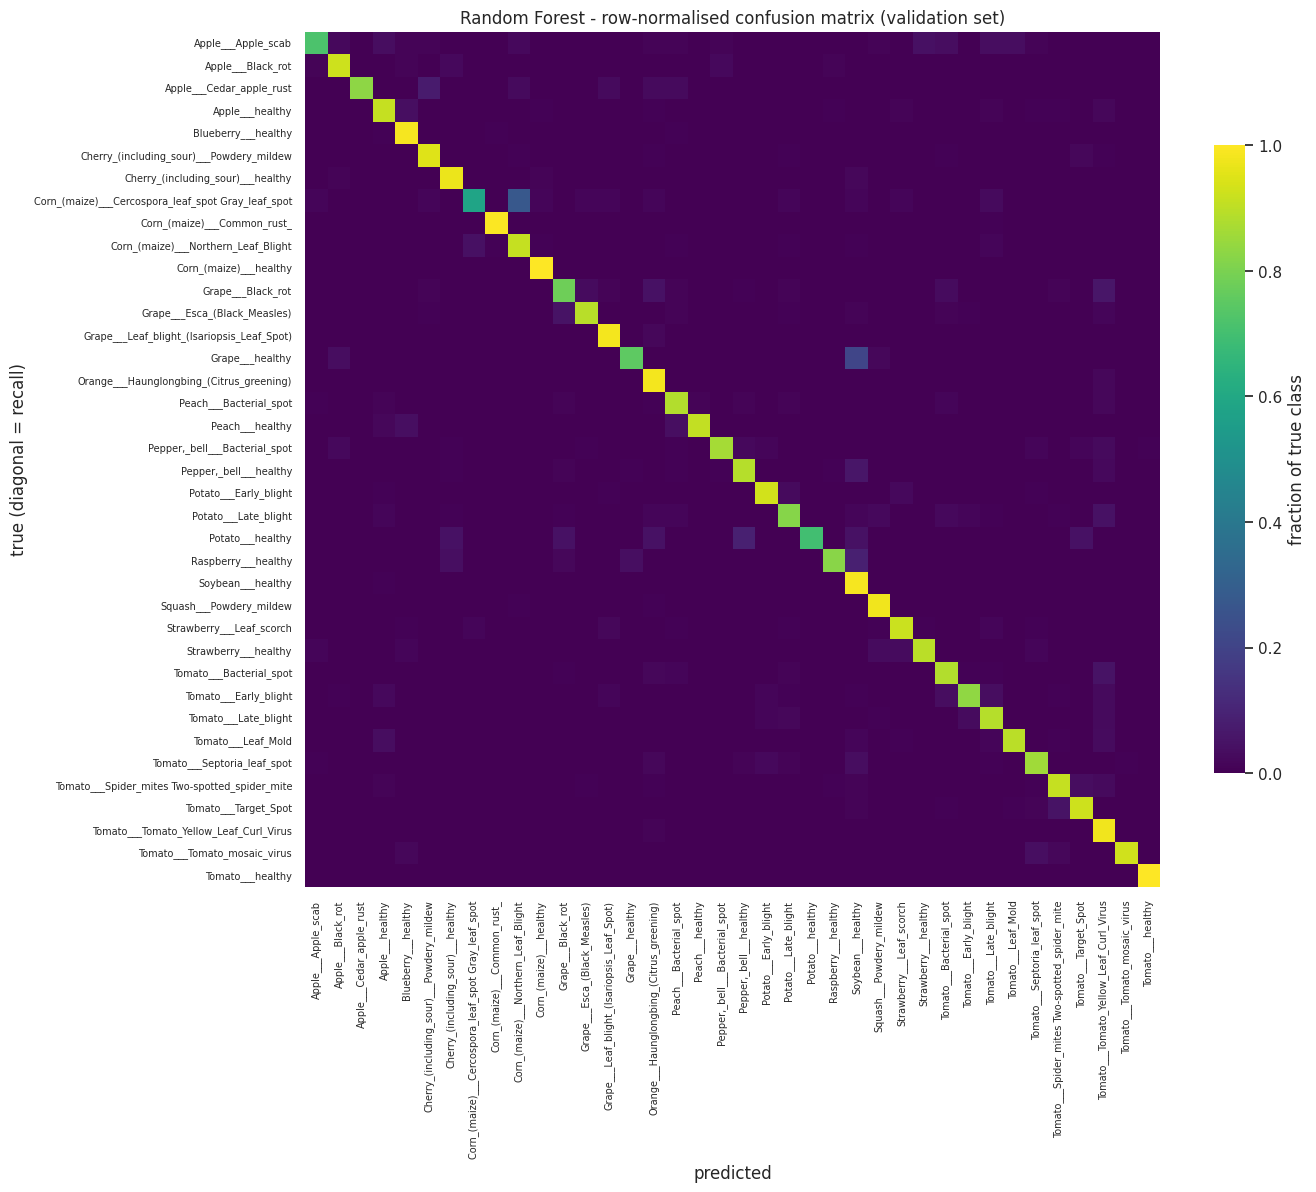

In [ ]:
# Confusion matrix, row-normalised so the diagonal reads as per-class recall
cm = confusion_matrix(yval_i, y_pred, labels=range(n_classes)).astype(float)
cm_norm = np.divide(cm, cm.sum(axis=1, keepdims=True),
                    out=np.zeros_like(cm), where=cm.sum(axis=1, keepdims=True) > 0)
plt.figure(figsize=(14, 12))
sns.heatmap(cm_norm, cmap="viridis", vmin=0, vmax=1, square=True,
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={"shrink": 0.7, "label": "fraction of true class"})
plt.xticks(rotation=90, fontsize=7); plt.yticks(rotation=0, fontsize=7)
plt.xlabel("predicted"); plt.ylabel("true (diagonal = recall)")
plt.title("Random Forest - row-normalised confusion matrix (validation set)")
plt.tight_layout(); plt.show()

## 8. What the forest used — importance by feature group

A Random Forest reports how much each feature reduced impurity. Summing those by **group** (RGB histogram / HSV histogram / GLCM texture / the six global features) shows at a glance which kind of information the model actually relied on.

Importance by feature group (sums to 1):
rgb_hist        0.421
hsv_hist        0.411
glcm_texture    0.096
global6         0.072


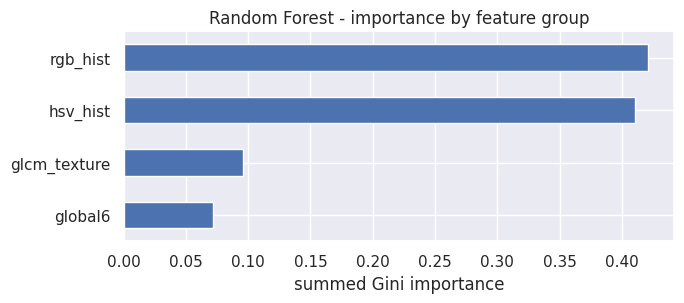

In [ ]:
# Which feature FAMILY does the forest lean on? (importances summed by group)
imp = pd.Series(rf.feature_importances_, index=FEATURE_GROUPS).groupby(level=0).sum().sort_values()
print("Importance by feature group (sums to 1):")
print(imp.sort_values(ascending=False).round(3).to_string())

plt.figure(figsize=(7, 3.2))
imp.plot(kind="barh", color="#4c72b0")
plt.xlabel("summed Gini importance"); plt.title("Random Forest - importance by feature group")
plt.tight_layout(); plt.show()

## 9. Save the trained model

Persist the forest and its validation metrics so this result is reproducible and ready to fold into a combined comparison later.

In [ ]:
# Save the trained forest + its validation metrics
try:
    joblib.dump(rf, RF_DIR / "random_forest.joblib")
    per_class.to_csv(RF_DIR / "rf_per_class_recall.csv", index=False)
    imp.sort_values(ascending=False).to_csv(RF_DIR / "rf_group_importance.csv", header=["importance"])
    with open(RF_DIR / "rf_run_config.json", "w") as f:
        json.dump({"feat_size": FEAT_SIZE, "rgb_bins": RGB_BINS, "hsv_bins": HSV_BINS,
                   "glcm_levels": GLCM_LEVELS, "n_estimators": N_ESTIMATORS,
                   "n_features": len(FEATURE_NAMES), "seed": SEED,
                   "n_train_fit": int(Xtr.shape[0]), "n_val": int(Xval.shape[0]),
                   "macro_F1": round(float(rf_mf1), 4), "accuracy": round(float(rf_acc), 4),
                   "smoke_test": SMOKE_TEST}, f, indent=2)
    print("Saved RF model + metrics to:", RF_DIR)
except Exception as e:
    print("Save skipped:", e)

Saved RF model + metrics to: /root/plant_recognition/step3_rf


## 10. Reading the result

The two things that matter are the forest's **validation macro-F1** (Section 7) and where its **per-class recall** is weakest — typically the rarest classes and visually similar diseases within a crop, which the confusion matrix makes visible. The **group-importance** plot says which features carried that signal.

This is one classical baseline **in isolation**; placing it next to the other models in a single comparison table is the next step, done separately. The **held-out test set stays sealed** — the honest final figure is reserved for Deliverable 2.

**Artifacts saved:** `random_forest.joblib`, `rf_per_class_recall.csv`, `rf_group_importance.csv`, `rf_run_config.json`, and the cached feature matrices.